In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Context

In [21]:
titanic_data = pd.read_csv('train.csv', index_col='PassengerId')
titanic_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
0,1,1,"Oconnor, Frankie",male,NaN,2,0,209245,27.14,C12239,S
1,0,3,"Bryan, Drew",male,NaN,0,0,27323,13.35,NaN,S
2,0,3,"Owens, Kenneth",male,0.33,1,2,CA 457703,71.29,NaN,S
3,0,3,"Kramer, James",male,19.00,0,0,A. 10866,13.04,NaN,S
4,1,3,"Bond, Michael",male,25.00,0,0,427635,7.76,NaN,S


# Data quality assessment

In [22]:
print(f'Shape: {titanic_data.shape}')

Shape: (100000, 11)


In [24]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Survived  100000 non-null  int64  
 1   Pclass    100000 non-null  int64  
 2   Name      100000 non-null  object 
 3   Sex       100000 non-null  object 
 4   Age       96708 non-null   float64
 5   SibSp     100000 non-null  int64  
 6   Parch     100000 non-null  int64  
 7   Ticket    95377 non-null   object 
 8   Fare      99866 non-null   float64
 9   Cabin     32134 non-null   object 
 10  Embarked  99750 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 9.2+ MB


In [25]:
duplicate_rows = titanic_data.loc[titanic_data.duplicated().values]
duplicate_rows_count = duplicate_rows.shape[0]
print(f'Duplicate rows count: {duplicate_rows_count}')

Duplicate rows count: 0


In [26]:
survived_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.Survived)].Survived.shape[0] / titanic_data.Survived.shape[0] * 100, 2 )
pclass_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.Survived)].Pclass.shape[0] / titanic_data.Pclass.shape[0] * 100, 2)
name_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.Name)].Name.shape[0] / titanic_data.Name.shape[0] * 100, 2)
sex_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.Sex)].Sex.shape[0] / titanic_data.Sex.shape[0] * 100, 2)
age_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.Age)].Age.shape[0] / titanic_data.Age.shape[0] * 100, 2)
sibsp_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.SibSp)].SibSp.shape[0] / titanic_data.SibSp.shape[0] * 100, 2)
parch_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.Parch)].Parch.shape[0] / titanic_data.Parch.shape[0] * 100, 2)
ticket_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.Ticket)].Ticket.shape[0] / titanic_data.Ticket.shape[0] * 100, 2)
fare_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.Fare)].Fare.shape[0] / titanic_data.Fare.shape[0] * 100, 2)
cabin_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.Cabin)].Cabin.shape[0] / titanic_data.Cabin.shape[0] * 100, 2)
embarked_not0_percent = round(titanic_data.loc[pd.notna(titanic_data.Embarked)].Embarked.shape[0] / titanic_data.Embarked.shape[0] * 100, 2)

column_names = titanic_data.columns.tolist()
notnull_percent = pd.DataFrame({'not-null, %': [survived_not0_percent, pclass_not0_percent, name_not0_percent, sex_not0_percent, age_not0_percent, sibsp_not0_percent, 
                                                parch_not0_percent, ticket_not0_percent, fare_not0_percent, cabin_not0_percent, embarked_not0_percent]}, index=[column_names])

notnull_percent

,"not-null, %"
Survived,100.00
Pclass,100.00
Name,100.00
Sex,100.00
Age,96.71
SibSp,100.00
Parch,100.00
Ticket,95.38
Fare,99.87
Cabin,32.13


# Data exploration

In [27]:
titanic_data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,100000.000000,100000.000000,96708.000000,100000.000000,100000.000000,99866.00000
mean,0.427740,2.106910,38.355472,0.397690,0.454560,43.92933
std,0.494753,0.837727,18.313556,0.862566,0.950076,69.58882
min,0.000000,1.000000,0.080000,0.000000,0.000000,0.68000
25%,0.000000,1.000000,25.000000,0.000000,0.000000,10.04000
50%,0.000000,2.000000,39.000000,0.000000,0.000000,24.46000
75%,1.000000,3.000000,53.000000,1.000000,1.000000,33.50000
max,1.000000,3.000000,87.000000,8.000000,9.000000,744.66000


42.77% of passangers survived


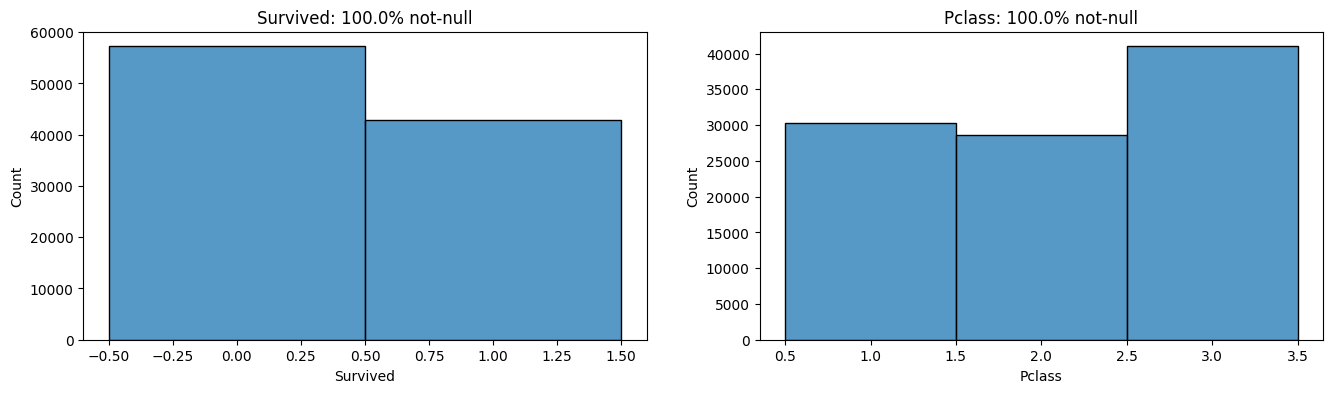

In [28]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))
sns.histplot(data = titanic_data, x = 'Survived', discrete=True, ax = axes[0])
axes[0].set_title(f'Survived: {survived_not0_percent}% not-null')

sns.histplot(data = titanic_data, x = 'Pclass', discrete=True, ax = axes[1])
axes[1].set_title(f'Pclass: {pclass_not0_percent}% not-null')

survived_percent = ((titanic_data.Survived[titanic_data['Survived'] == 1].count()) / (titanic_data.Survived.count()) * 100).round(2)
print(f'{survived_percent}% of passangers survived')

Text(0.5, 1.0, 'Sex: 100.0% not-null')

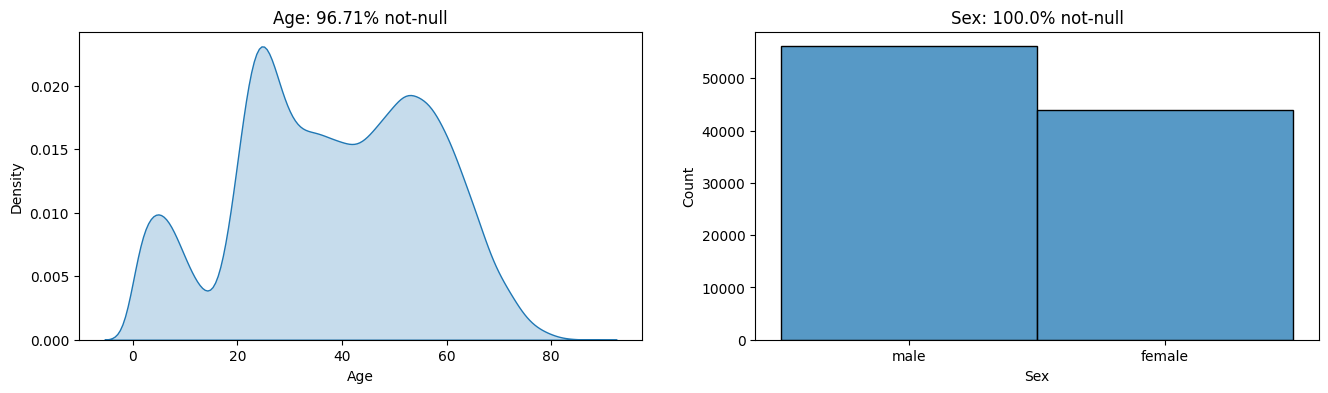

In [29]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))
sns.kdeplot(data = titanic_data['Age'], fill = True, ax = axes[0])
axes[0].set_title(f'Age: {age_not0_percent}% not-null')

sns.histplot(titanic_data, x = 'Sex', discrete=True, ax = axes[1])
axes[1].set_title(f'Sex: {sex_not0_percent}% not-null')

73.54% of passangers fly without any Parents/Children


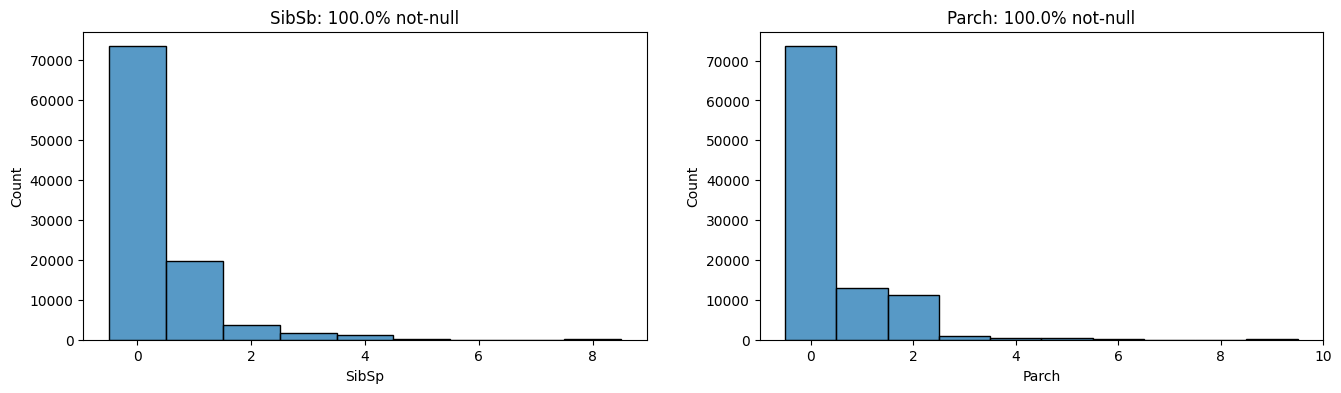

In [30]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))
sns.histplot(titanic_data, x ='SibSp', discrete=True, ax = axes[0])
axes[0].set_title(f'SibSb: {sibsp_not0_percent}% not-null')

sns.histplot(titanic_data, x = 'Parch', discrete=True, ax = axes[1])
axes[1].set_title(f'Parch: {parch_not0_percent}% not-null')

children_parents_percent = ((titanic_data.Parch[titanic_data['Parch'] == 0].count()) / (titanic_data.Parch.count()) * 100).round(2)
print(f'{children_parents_percent}% of passangers fly without any Parents/Children')


Percent of `S` Embarked : 72.14%


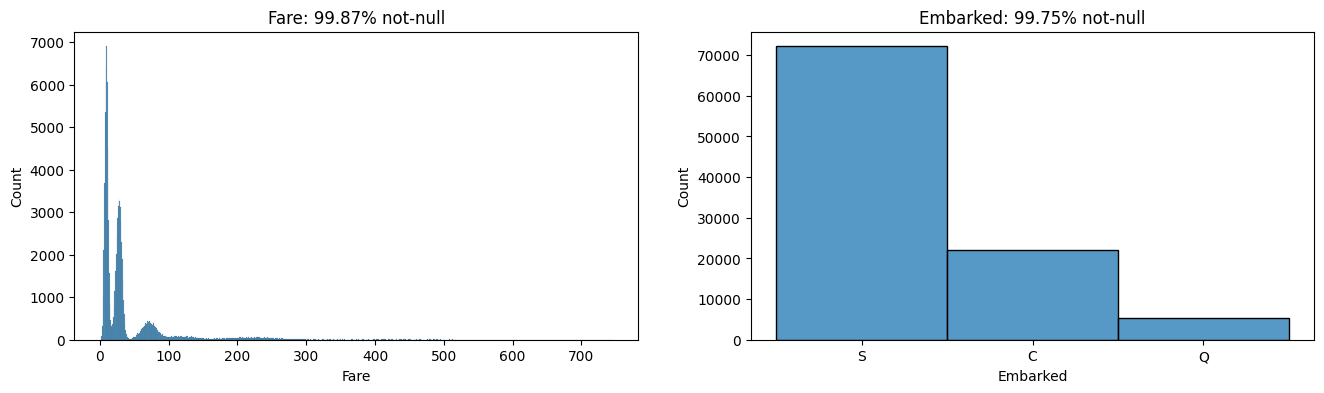

In [31]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))
sns.histplot(titanic_data, x ='Fare', discrete=True, ax = axes[0])
axes[0].set_title(f'Fare: {fare_not0_percent}% not-null')

sns.histplot(titanic_data, x = 'Embarked', discrete=True, ax = axes[1])
axes[1].set_title(f'Embarked: {embarked_not0_percent}% not-null')

embarked_percent = ((titanic_data.Embarked[titanic_data['Embarked'] == 'S'].count()) / (titanic_data.Parch.count()) * 100).round(2)
print(f'Percent of `S` Embarked : {embarked_percent}%')

In [33]:
titanic_data['LastName'] = titanic_data.Name.map(lambda p: p.split(',')[0])
titanic_data['FirstName'] = titanic_data.Name.map(lambda p: p.split(',')[1])
titanic_data.Name.describe()

count            100000
unique            92144
top       Johnson, John
freq                 31
Name: Name, dtype: object

Text(0, 0.5, 'Name')

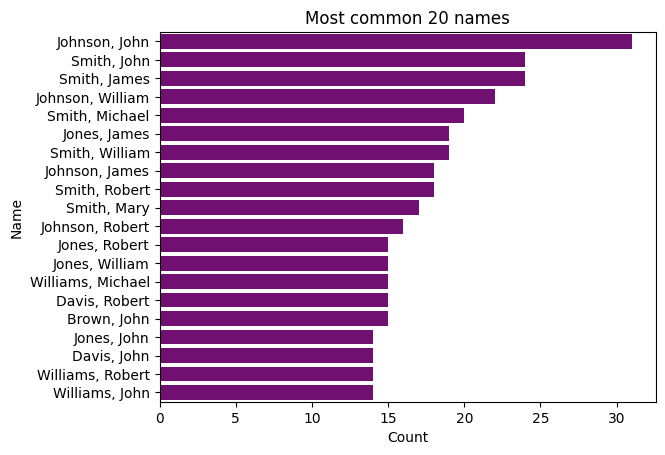

In [40]:
top_names = titanic_data.groupby('Name').FirstName.count().sort_values(ascending = False)

sns.barplot(y=top_names.iloc[0:20].index, x = top_names.iloc[0:20].values, color = 'purple')
plt.title('Most common 20 names') 
plt.xlabel('Count')
plt.ylabel('Name')

Text(0, 0.5, 'First Name')

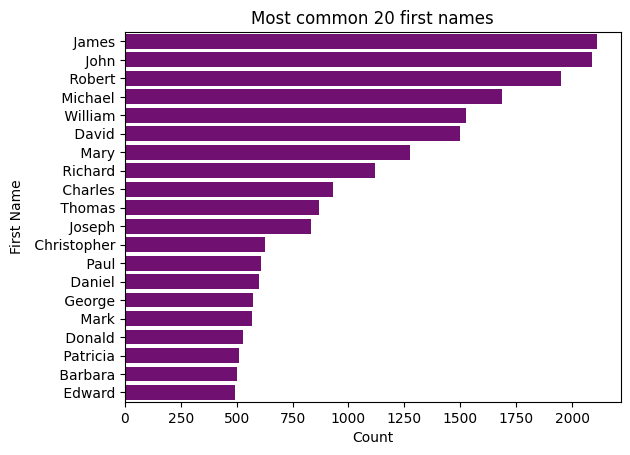

In [41]:
top_names = titanic_data.groupby('FirstName').FirstName.count().sort_values(ascending = False)

sns.barplot(y=top_names.iloc[0:20].index, x = top_names.iloc[0:20].values, color = 'purple')
plt.title('Most common 20 first names') 
plt.xlabel('Count')
plt.ylabel('First Name')

Text(0, 0.5, 'Last Name')

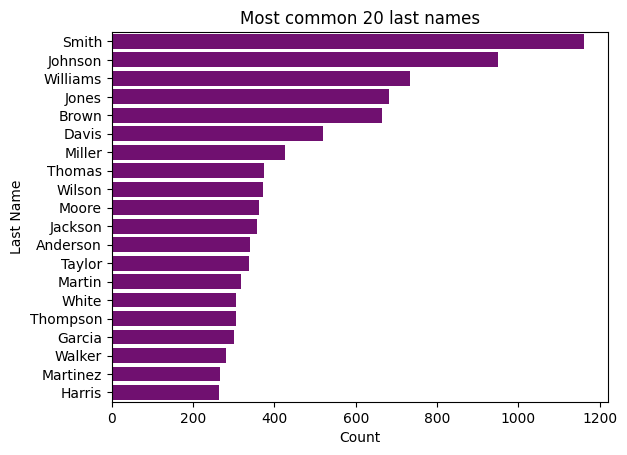

In [42]:
top_names = titanic_data.groupby('LastName').LastName.count().sort_values(ascending = False)

sns.barplot(y=top_names.iloc[0:20].index, x = top_names.iloc[0:20].values, color = 'purple')
plt.title('Most common 20 last names') 
plt.xlabel('Count')
plt.ylabel('Last Name')

In [43]:
titanic_data.Ticket.describe()

count     95377
unique    75331
top        A/5 
freq        602
Name: Ticket, dtype: object

Text(0, 0.5, 'Ticket')

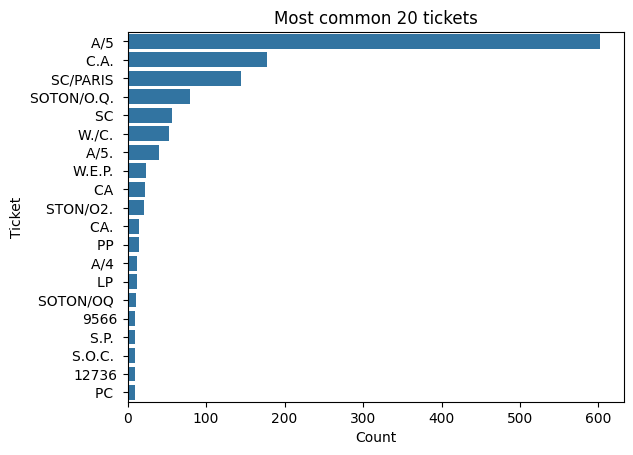

In [44]:
top_ticket_names = titanic_data.groupby('Ticket').Ticket.count().sort_values(ascending = False)

sns.barplot(y=top_ticket_names.iloc[0:20].index, x = top_ticket_names.iloc[0:20].values)
plt.title('Most common 20 tickets') 
plt.xlabel('Count')
plt.ylabel('Ticket')

In [45]:
titanic_data.Cabin.describe()

count      32134
unique     26992
top       C19828
freq           6
Name: Cabin, dtype: object

Text(0, 0.5, 'Cabins')

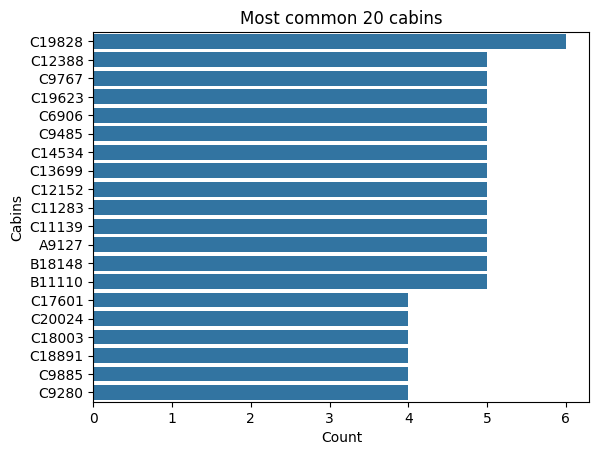

In [46]:
top_cabin_names = titanic_data.groupby('Cabin').Cabin.count().sort_values(ascending = False)

sns.barplot(y=top_cabin_names.iloc[0:20].index, x = top_cabin_names.iloc[0:20].values)
plt.title('Most common 20 cabins') 
plt.xlabel('Count')
plt.ylabel('Cabins')

Text(0.5, 1.0, 'Fare / Age relationship')

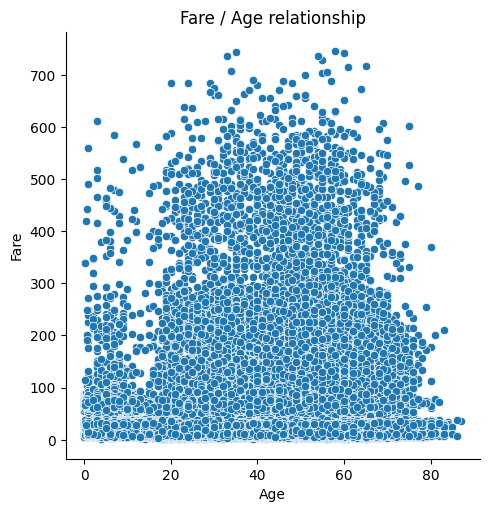

In [47]:
sns.relplot(data=titanic_data, x="Age", y="Fare")
plt.title('Fare / Age relationship')

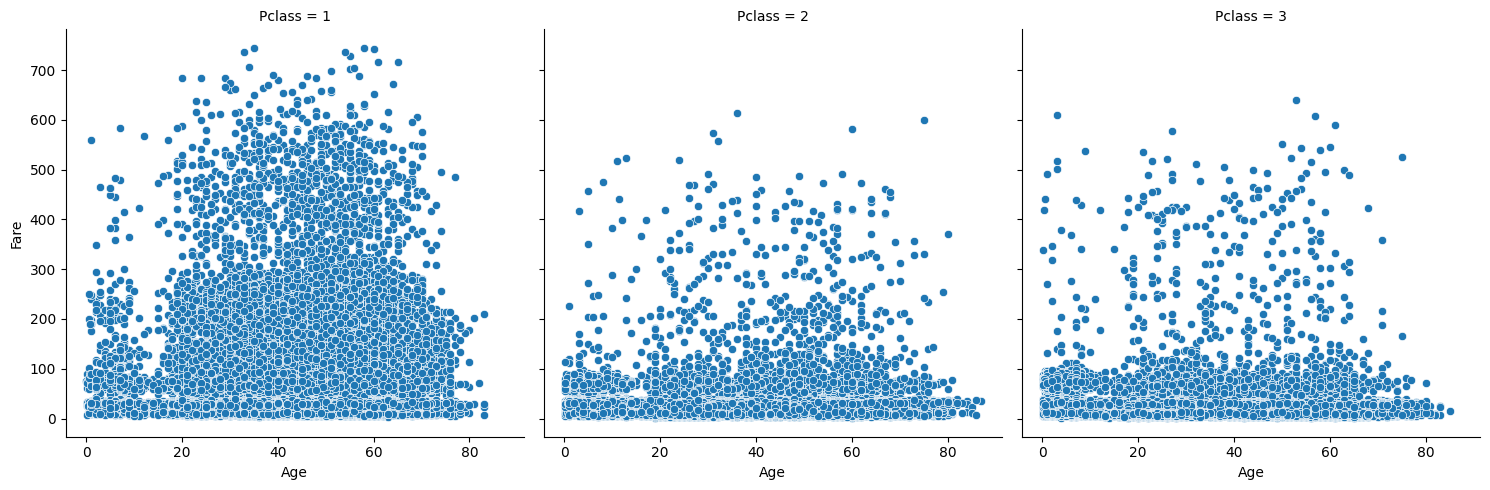

In [48]:
sns.relplot(data=titanic_data, x="Age", y="Fare", col='Pclass')

Text(0.5, 0, 'Passenger class')

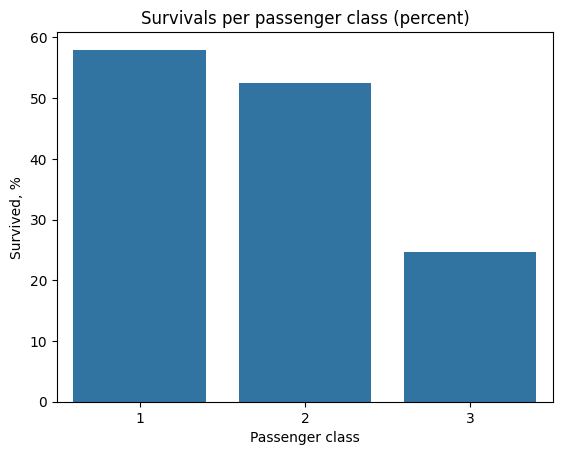

In [50]:
pclass_total_stats = titanic_data.groupby(['Pclass']).Name.count()
pclass_stats = pd.DataFrame(data = pclass_total_stats)
pclass_stats = pclass_stats.rename(columns = {'Name':'Total'})
pclass_stats['Survived'] = titanic_data.loc[titanic_data.Survived == True].groupby(['Pclass']).Name.count()
pclass_stats['Survived_percent'] = round(pclass_stats.Survived / pclass_stats.Total * 100, 2)

sns.barplot(x = pclass_stats.index, y = pclass_stats.Survived_percent)
plt.title('Survivals per passenger class (percent)')
plt.ylabel('Survived, %')
plt.xlabel('Passenger class')

(0.0, 60.0)

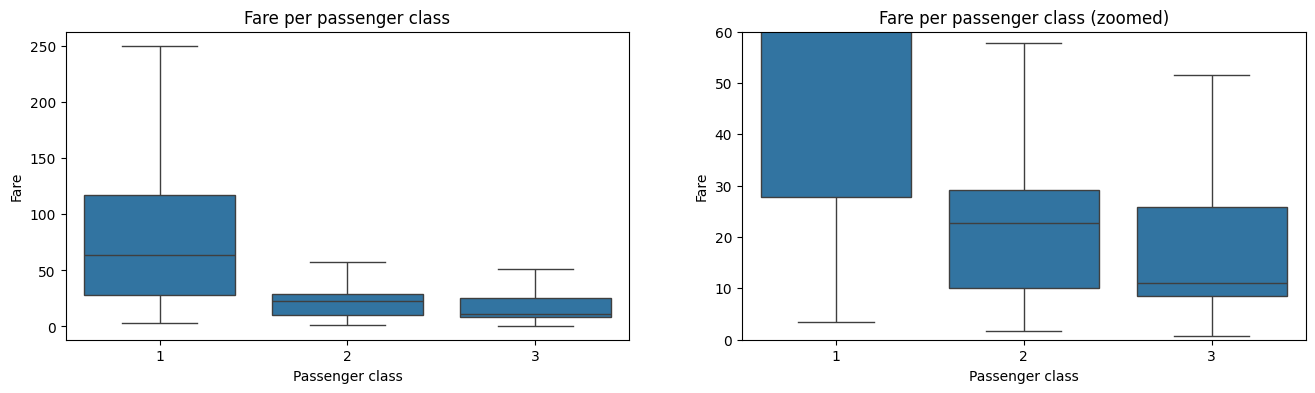

In [52]:
fig, axes = plt.subplots(ncols = 2, nrows = 1, figsize = (16,4))
sns.boxplot(data=titanic_data, x="Pclass", y="Fare", showfliers = False, ax = axes[0])
axes[0].set_title('Fare per passenger class')
axes[0].set_ylabel('Fare')
axes[0].set_xlabel('Passenger class')

sns.boxplot(data=titanic_data, x="Pclass", y="Fare", showfliers = False, ax = axes[1])
axes[1].set_title('Fare per passenger class (zoomed)')
axes[1].set_ylabel('Fare')
axes[1].set_xlabel('Passenger class')
axes[1].set_ylim(0,60)

(0.0, 60.0)

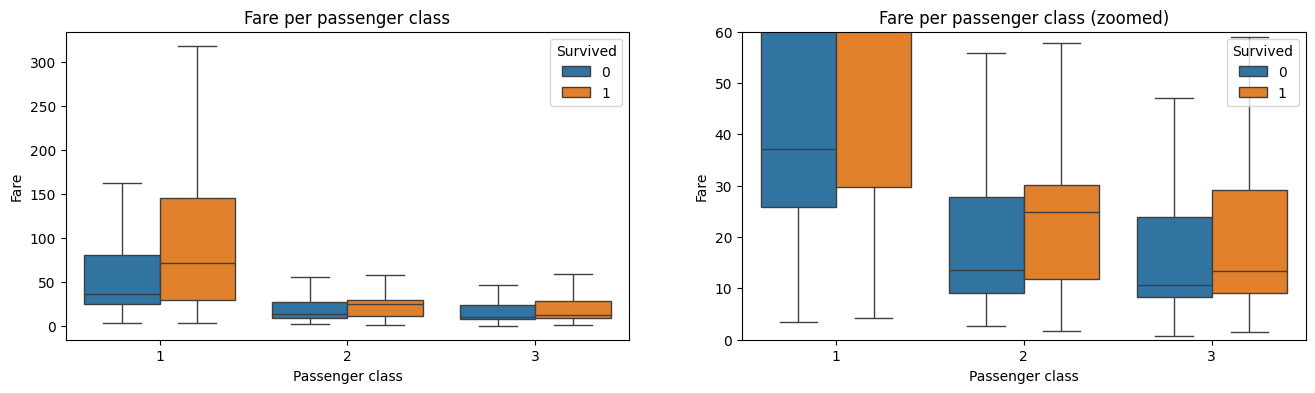

In [53]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))

sns.boxplot(data=titanic_data, x="Pclass", y="Fare", hue="Survived", showfliers = False, ax = axes[0])
axes[0].set_title('Fare per passenger class')
axes[0].set_ylabel('Fare')
axes[0].set_xlabel('Passenger class')

sns.boxplot(data=titanic_data, x="Pclass", y="Fare", hue="Survived", showfliers = False, ax = axes[1])
axes[1].set_title('Fare per passenger class (zoomed)')
axes[1].set_ylabel('Fare')
axes[1].set_xlabel('Passenger class')
axes[1].set_ylim(0, 60)

To survive, it is better to overpay for the flight.

Text(0.5, 0, 'Passenger class')

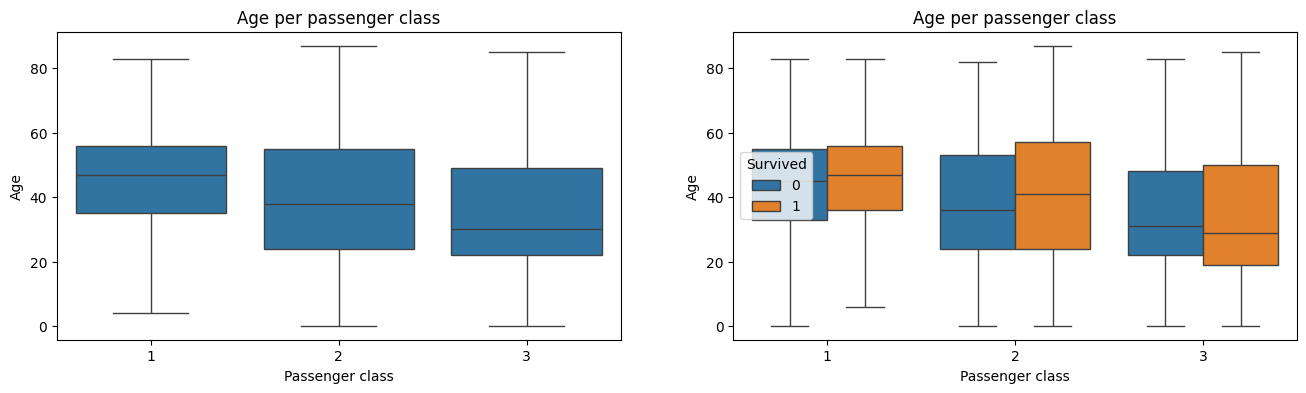

In [55]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))

sns.boxplot(data=titanic_data, x="Pclass", y="Age", showfliers = False, ax = axes[0])
axes[0].set_title('Age per passenger class')
axes[0].set_ylabel('Age')
axes[0].set_xlabel('Passenger class')

sns.boxplot(data=titanic_data, x="Pclass", y="Age", hue='Survived', showfliers = False, ax = axes[1])
axes[1].set_title('Age per passenger class')
axes[1].set_ylabel('Age')
axes[1].set_xlabel('Passenger class')

The older the passenger, the higher the flight class.

In [56]:
def child_adult(row): 
    if (row.Age >= 18):
        row.ChildAdult = 'Adult'
    elif (row.Age < 18 and row.Age >= 0):
        row.ChildAdult = 'Child'
    else:
        row.ChildAdult = np.nan 
    return row

titanic_data['ChildAdult'] = titanic_data['Sex']
titanic_data = titanic_data.apply(child_adult, axis='columns')
titanic_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,LastName,FirstName,ChildAdult
PassengerId,,,,,,,,,,,,,,
0,1,1,"Oconnor, Frankie",male,NaN,2,0,209245,27.14,C12239,S,Oconnor,Frankie,NaN
1,0,3,"Bryan, Drew",male,NaN,0,0,27323,13.35,NaN,S,Bryan,Drew,NaN
2,0,3,"Owens, Kenneth",male,0.33,1,2,CA 457703,71.29,NaN,S,Owens,Kenneth,Child
3,0,3,"Kramer, James",male,19.00,0,0,A. 10866,13.04,NaN,S,Kramer,James,Adult
4,1,3,"Bond, Michael",male,25.00,0,0,427635,7.76,NaN,S,Bond,Michael,Adult


Percent of children : 12.32%


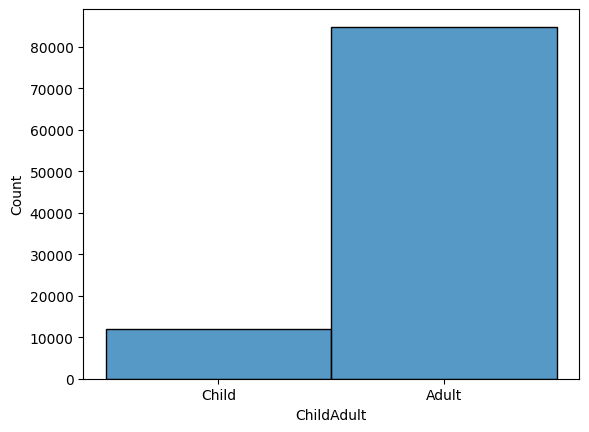

In [57]:
sns.histplot(titanic_data['ChildAdult'])

child_percent = ((titanic_data.ChildAdult[titanic_data['ChildAdult'] == 'Child'].count()) / (titanic_data.ChildAdult.count()) * 100).round(2)
print(f'Percent of children : {child_percent}%')

Text(0.5, 0, 'Age')

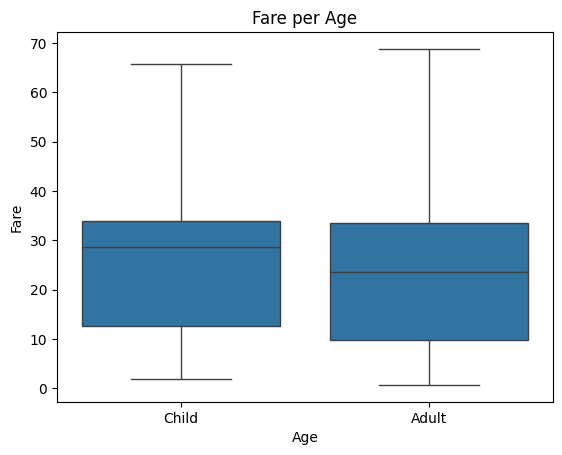

In [58]:
sns.boxplot(data=titanic_data, x="ChildAdult", y="Fare", showfliers = False)
plt.title('Fare per Age')
plt.ylabel('Fare')
plt.xlabel('Age')

Text(0.5, 0, 'Age')

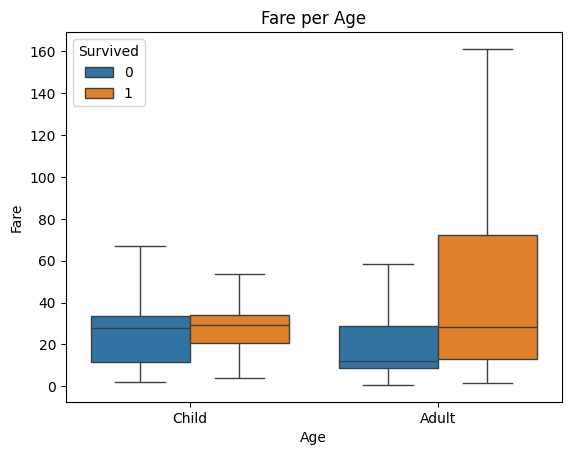

In [60]:
sns.boxplot(data=titanic_data, x="ChildAdult", y="Fare", hue = 'Survived', showfliers = False)
plt.title('Fare per Age')
plt.ylabel('Fare')
plt.xlabel('Age')

In [61]:
titanic_data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,LastName,FirstName,ChildAdult
PassengerId,,,,,,,,,,,,,,
0,1,1,"Oconnor, Frankie",male,NaN,2,0,209245,27.14,C12239,S,Oconnor,Frankie,NaN
1,0,3,"Bryan, Drew",male,NaN,0,0,27323,13.35,NaN,S,Bryan,Drew,NaN
2,0,3,"Owens, Kenneth",male,0.33,1,2,CA 457703,71.29,NaN,S,Owens,Kenneth,Child
3,0,3,"Kramer, James",male,19.00,0,0,A. 10866,13.04,NaN,S,Kramer,James,Adult
4,1,3,"Bond, Michael",male,25.00,0,0,427635,7.76,NaN,S,Bond,Michael,Adult


C:\Users\krekesh\AppData\Local\Temp\ipykernel_6448\619136499.py:1: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  children = int(titanic_data.ChildAdult[titanic_data.ChildAdult == 'Child'].value_counts())
C:\Users\krekesh\AppData\Local\Temp\ipykernel_6448\619136499.py:2: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  adults = int(titanic_data.ChildAdult[titanic_data.ChildAdult == 'Adult'].value_counts())
C:\Users\krekesh\AppData\Local\Temp\ipykernel_6448\619136499.py:3: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  survived_children = int(titanic_data.ChildAdult[(titanic_data.ChildAdult == 'Child') & (titanic_data.Survived == 1)].value_counts())
C:\Users\krekesh\AppData\Local\Temp\ipykernel_6448\619136499.py

<Axes: xlabel='ChildAdult'>

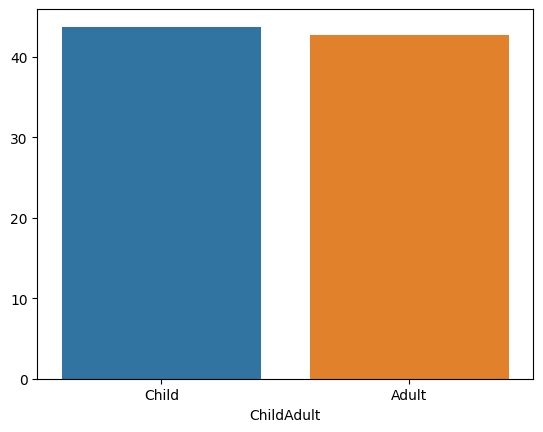

In [80]:
children = int(titanic_data.ChildAdult[titanic_data.ChildAdult == 'Child'].value_counts())
adults = int(titanic_data.ChildAdult[titanic_data.ChildAdult == 'Adult'].value_counts())
survived_children = int(titanic_data.ChildAdult[(titanic_data.ChildAdult == 'Child') & (titanic_data.Survived == 1)].value_counts())
survived_adults = int(titanic_data.ChildAdult[(titanic_data.ChildAdult == 'Adult') & (titanic_data.Survived == 1)].value_counts())
survived_children_percent = round(survived_children / children * 100, 3)
survived_adults_percent = round(survived_adults / adults * 100, 3)

sns.barplot(x = titanic_data.ChildAdult[titanic_data.ChildAdult == 'Child'], y = survived_children_percent)
sns.barplot(x = titanic_data.ChildAdult[titanic_data.ChildAdult == 'Adult'], y = survived_adults_percent)

In [ ]:
Fare and survival rate do not greatly depend on whether the passenger is a child or an adult.

Text(0.5, 0, 'Sex')

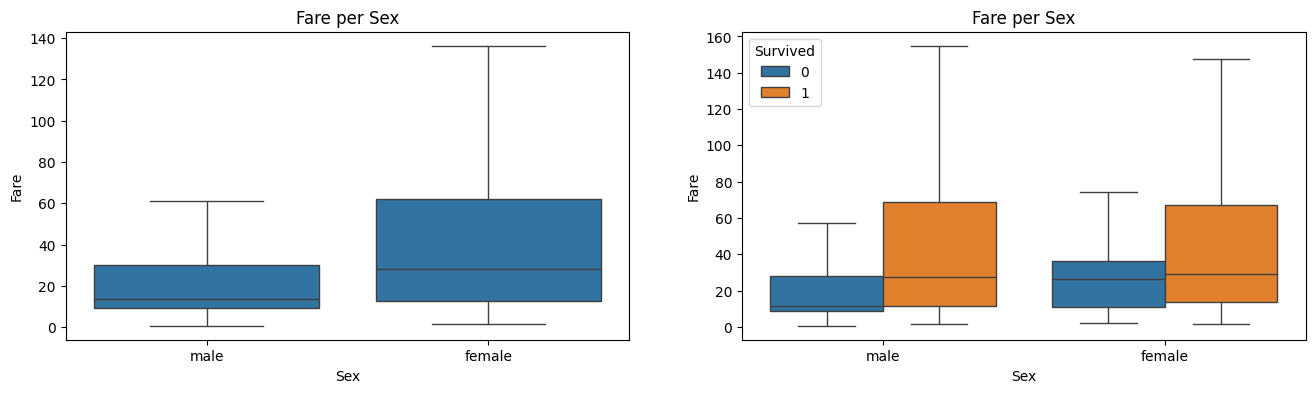

In [84]:
fig, axes = plt.subplots(ncols = 2, nrows = 1, figsize = (16,4))

sns.boxplot(data=titanic_data, x="Sex", y="Fare", showfliers = False, ax = axes[0])
axes[0].set_title('Fare per Sex')
axes[0].set_ylabel('Fare')
axes[0].set_xlabel('Sex')

sns.boxplot(data=titanic_data, x="Sex", y="Fare", hue = 'Survived', showfliers = False, ax = axes[1])
axes[1].set_title('Fare per Sex')
axes[1].set_ylabel('Fare')
axes[1].set_xlabel('Sex')

Text(0.5, 0, 'Number of Parents/Children')

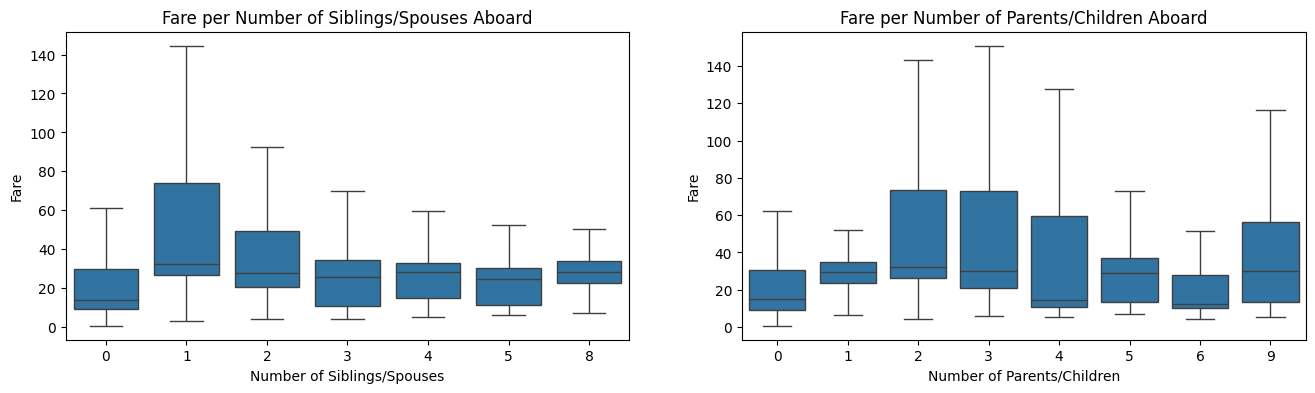

In [85]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))

sns.boxplot(data=titanic_data, x="SibSp", y="Fare", showfliers = False, ax = axes[0])
axes[0].set_title('Fare per Number of Siblings/Spouses Aboard')
axes[0].set_ylabel('Fare')
axes[0].set_xlabel('Number of Siblings/Spouses')

sns.boxplot(data=titanic_data, x="Parch", y="Fare", showfliers = False, ax = axes[1])
axes[1].set_title('Fare per Number of Parents/Children Aboard')
axes[1].set_ylabel('Fare')
axes[1].set_xlabel('Number of Parents/Children')

Text(0, 0.5, 'Name')

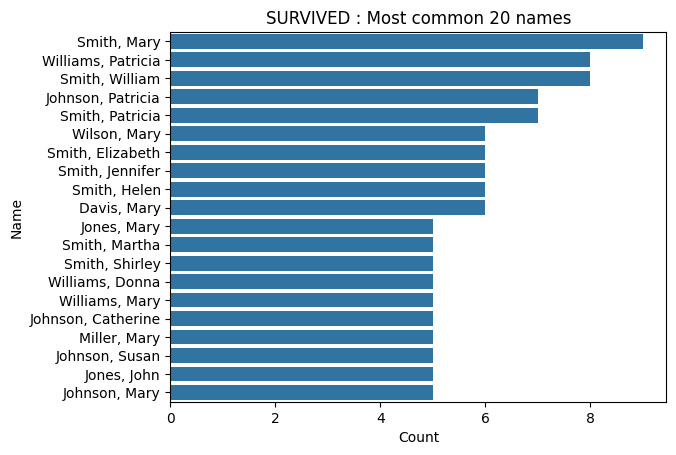

In [88]:
top_survived_names = titanic_data.loc[titanic_data.Survived == True].groupby('Name').Name.count().sort_values(ascending = False)

sns.barplot(y=top_survived_names.iloc[0:20].index, x = top_survived_names.iloc[0:20].values)
plt.title(f"SURVIVED : Most common 20 names")
plt.xlabel(f"Count")
plt.ylabel(f"Name")

Text(0, 0.5, 'Name')

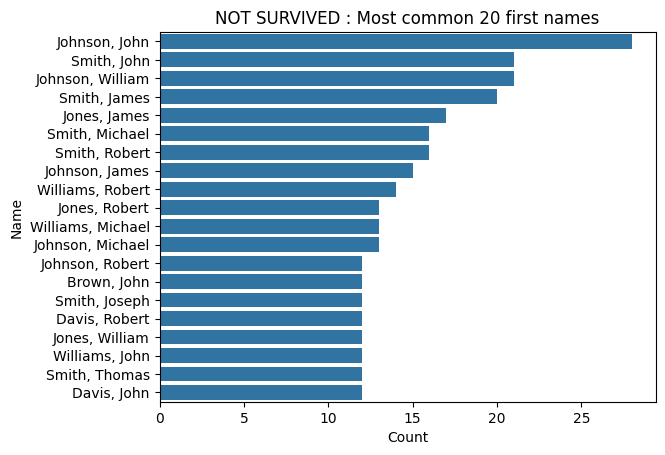

In [89]:
top_not_survived_names = titanic_data.loc[titanic_data.Survived == False].groupby('Name').Name.count().sort_values(ascending = False)

sns.barplot(y=top_not_survived_names.iloc[0:20].index, x = top_not_survived_names.iloc[0:20].values)
plt.title(f"NOT SURVIVED : Most common 20 first names")
plt.xlabel(f"Count")
plt.ylabel(f"Name")

Text(0, 0.5, 'first Name')

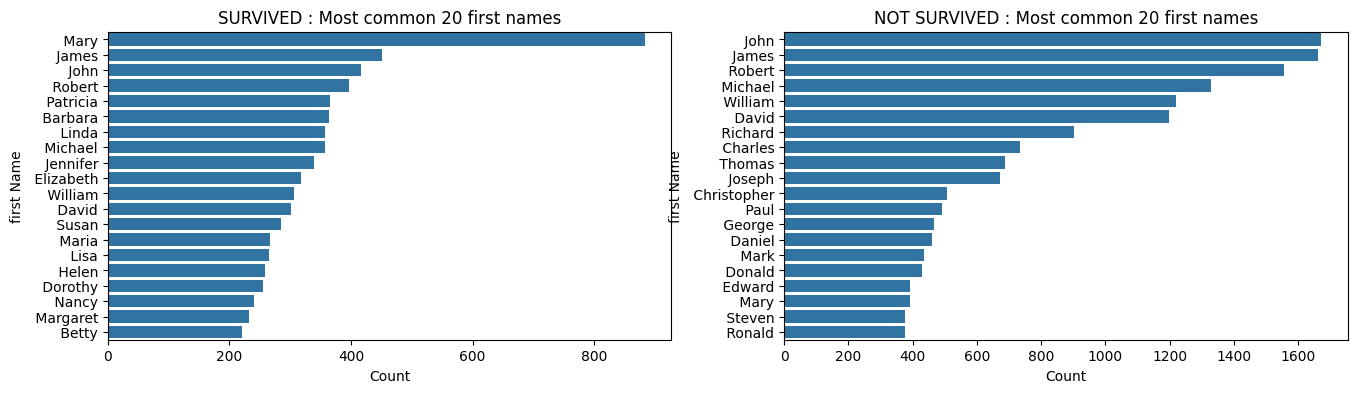

In [91]:
top_survived_first_names = titanic_data.loc[titanic_data.Survived == True].groupby('FirstName').Name.count().sort_values(ascending = False)
top_not_survived_first_names = titanic_data.loc[titanic_data.Survived == False].groupby('FirstName').Name.count().sort_values(ascending = False)
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))

sns.barplot(y=top_survived_first_names.iloc[0:20].index, x = top_survived_first_names.iloc[0:20].values , ax = axes[0])
axes[0].set_title(f"SURVIVED : Most common 20 first names")
axes[0].set_xlabel(f"Count")
axes[0].set_ylabel(f"first Name")

sns.barplot(y=top_not_survived_first_names.iloc[0:20].index, x = top_not_survived_first_names.iloc[0:20].values , ax = axes[1])
axes[1].set_title(f"NOT SURVIVED : Most common 20 first names")
axes[1].set_xlabel(f"Count")
axes[1].set_ylabel(f"first Name")

Text(0, 0.5, 'Last Name')

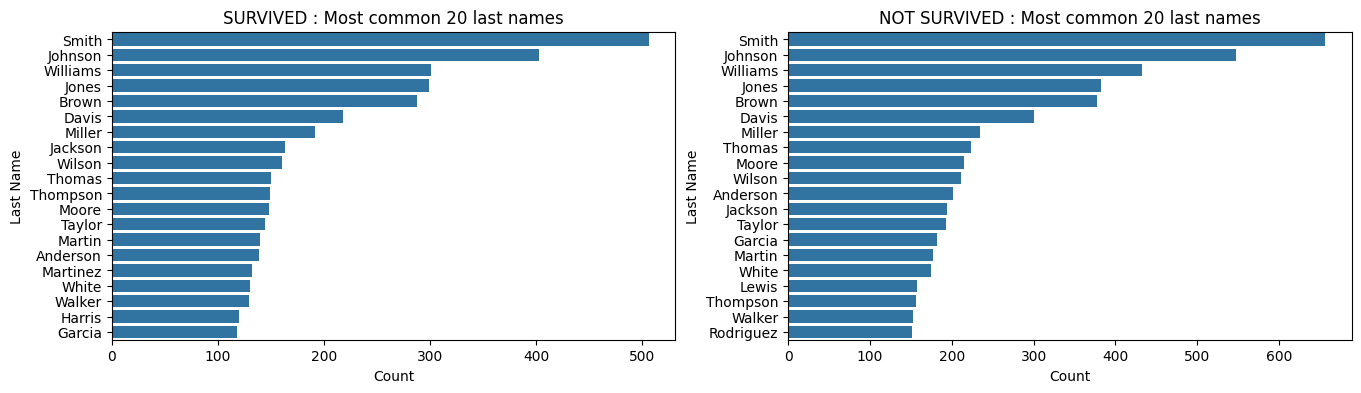

In [90]:
top_survived_last_names = titanic_data.loc[titanic_data.Survived == True].groupby('LastName').Name.count().sort_values(ascending = False)
top_not_survived_last_names = titanic_data.loc[titanic_data.Survived == False].groupby('LastName').Name.count().sort_values(ascending = False)
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))

sns.barplot(y=top_survived_last_names.iloc[0:20].index, x = top_survived_last_names.iloc[0:20].values , ax = axes[0])
axes[0].set_title(f"SURVIVED : Most common 20 last names")
axes[0].set_xlabel(f"Count")
axes[0].set_ylabel(f"Last Name")

sns.barplot(y=top_not_survived_last_names.iloc[0:20].index, x = top_not_survived_last_names.iloc[0:20].values , ax = axes[1])
axes[1].set_title(f"NOT SURVIVED : Most common 20 last names")
axes[1].set_xlabel(f"Count")
axes[1].set_ylabel(f"Last Name")

Text(0.5, 0, 'Embarked')

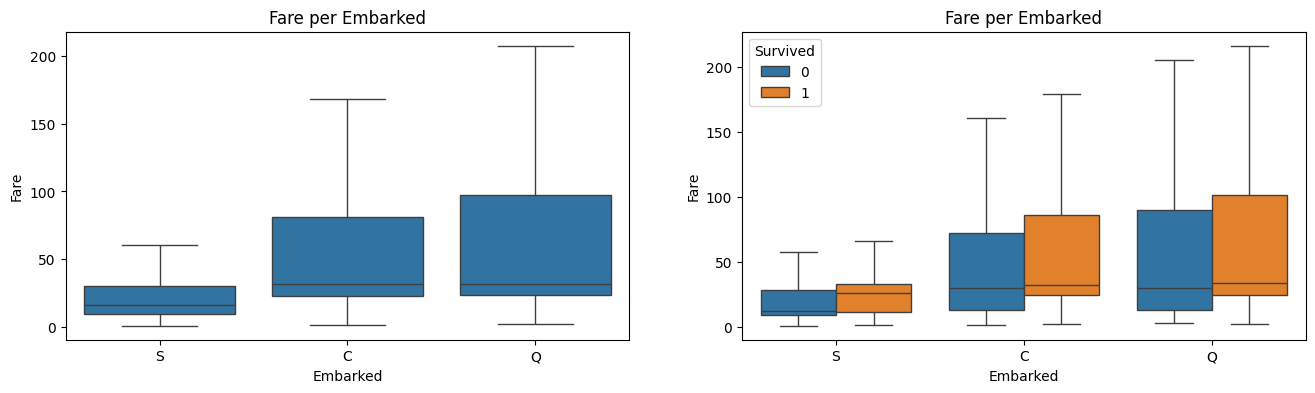

In [93]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))

sns.boxplot(data=titanic_data, x="Embarked", y="Fare", showfliers = False, ax = axes[0])
axes[0].set_title('Fare per Embarked')
axes[0].set_ylabel('Fare')
axes[0].set_xlabel('Embarked')

sns.boxplot(data=titanic_data, x="Embarked", y="Fare", hue='Survived', showfliers = False)
axes[1].set_title('Fare per Embarked')
axes[1].set_ylabel('Fare')
axes[1].set_xlabel('Embarked')

Text(0.5, 0, 'Embarked')

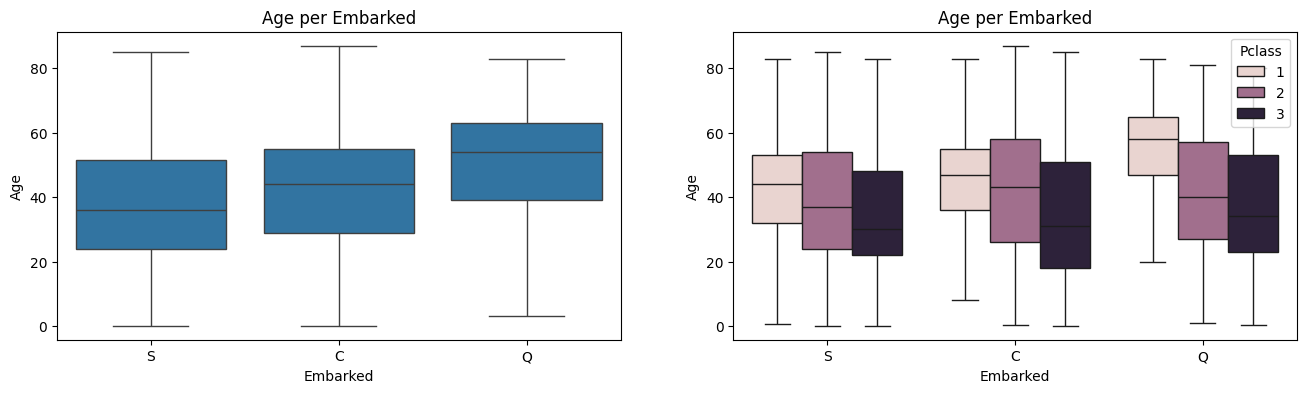

In [94]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(16,4))

sns.boxplot(data=titanic_data, x="Embarked", y="Age", showfliers = False, ax = axes[0])
axes[0].set_title('Age per Embarked')
axes[0].set_ylabel('Age')
axes[0].set_xlabel('Embarked')

sns.boxplot(data=titanic_data, x="Embarked", y="Age", hue='Pclass', showfliers = False)
axes[1].set_title('Age per Embarked')
axes[1].set_ylabel('Age')
axes[1].set_xlabel('Embarked')

# Summary

42.77% of passangers survived.
To survive it is better to fly first class.
The higher passenger class, the higher ticket fare.
The older the passenger, the higher the passenger class.
The passenger's age does not affect the ticket price.
The ticket price for female was higher than for male.
Passengers with 1 Sibling/Spouse on board pay the most per flight.
Passengers without Siblings/Spouses on board pay the least per flight.
Passengers with 2-3 Parent/Children on board pay the most per flight.
Passengers with 6 Parent/Children on board pay the least per flight.
The cheapest Embarked point is S (Southampton).
Most passengers(72.14%) choose Embarked point S (Southampton).